# Student Success Prediction — EDA & Modeling Walkthrough

This notebook mirrors the production pipeline in `src/` step by step, with
visualizations and inline commentary. It's meant for reviewers who want to see
the reasoning behind the pipeline, not just its final output.

**Dataset:** UCI *Predict Students' Dropout and Academic Success*
(Realinho et al., 2021) — 4,424 real students, 36 features, 3-class target.
See `data/README.md` for the full citation.

**Sections:**
1. Load & inspect the raw data
2. Exploratory Data Analysis (EDA)
3. Feature engineering
4. Train / validation / test split
5. Model comparison: Logistic Regression, Random Forest, XGBoost, LightGBM
6. Final model evaluation on the held-out test set
7. Explainability with SHAP
8. Risk scoring demo


In [1]:
import sys
from pathlib import Path

# Make `src` importable when running this notebook from notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)

from src import config
from src.data_processing import (
    load_raw_data, engineer_features, build_preprocessor,
    prepare_dataset, get_feature_lists, get_transformed_feature_names,
)

pd.set_option("display.max_columns", 50)


## 1. Load & Inspect the Raw Data

In [2]:
df = load_raw_data()
print(f"Shape: {df.shape}")
df.head()


Shape: (4424, 35)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

In [4]:
print("Missing values per column:", df.isna().sum().sum())
print()
print("Target distribution:")
print(df[config.TARGET_COLUMN].value_counts())
print()
print("Target distribution (%):")
print((df[config.TARGET_COLUMN].value_counts(normalize=True) * 100).round(1))


Missing values per column: 0

Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Target distribution (%):
Target
Graduate    49.9
Dropout     32.1
Enrolled    17.9
Name: proportion, dtype: float64


## 2. Exploratory Data Analysis

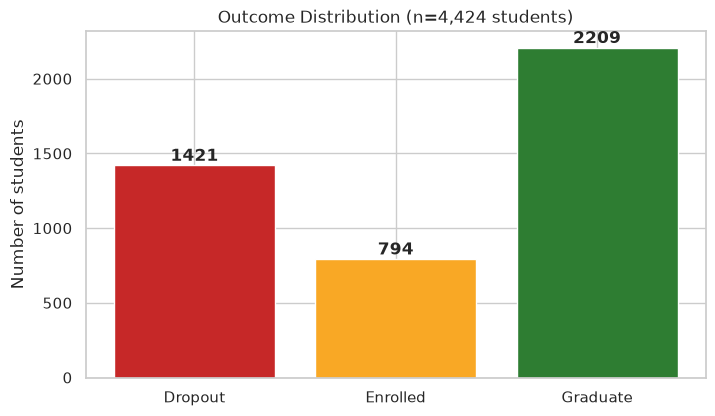

In [5]:
fig, ax = plt.subplots()
order = ["Dropout", "Enrolled", "Graduate"]
colors = {"Dropout": "#C62828", "Enrolled": "#F9A825", "Graduate": "#2E7D32"}
counts = df[config.TARGET_COLUMN].value_counts().reindex(order)
ax.bar(counts.index, counts.values, color=[colors[c] for c in counts.index])
ax.set_title("Outcome Distribution (n=4,424 students)")
ax.set_ylabel("Number of students")
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, str(v), ha="center", fontweight="bold")
plt.show()


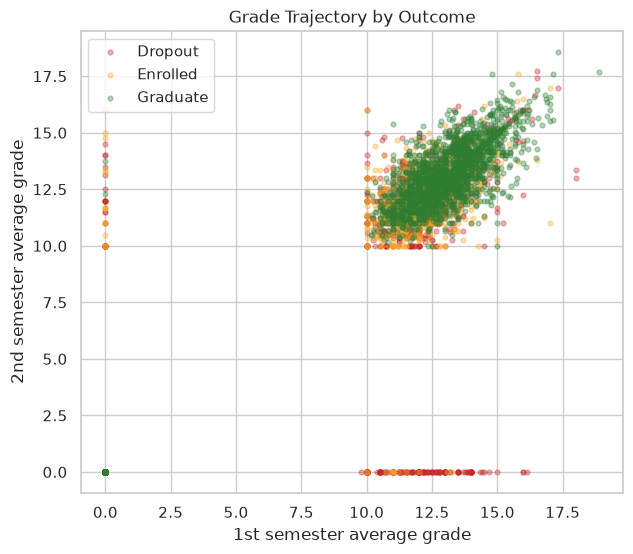

In [6]:
# Grade trajectory by outcome: does 2nd semester performance track 1st semester?
fig, ax = plt.subplots(figsize=(7, 6))
for outcome in order:
    subset = df[df[config.TARGET_COLUMN] == outcome]
    ax.scatter(
        subset["Curricular units 1st sem (grade)"],
        subset["Curricular units 2nd sem (grade)"],
        alpha=0.35, s=12, label=outcome, color=colors[outcome],
    )
ax.set_xlabel("1st semester average grade")
ax.set_ylabel("2nd semester average grade")
ax.set_title("Grade Trajectory by Outcome")
ax.legend()
plt.show()


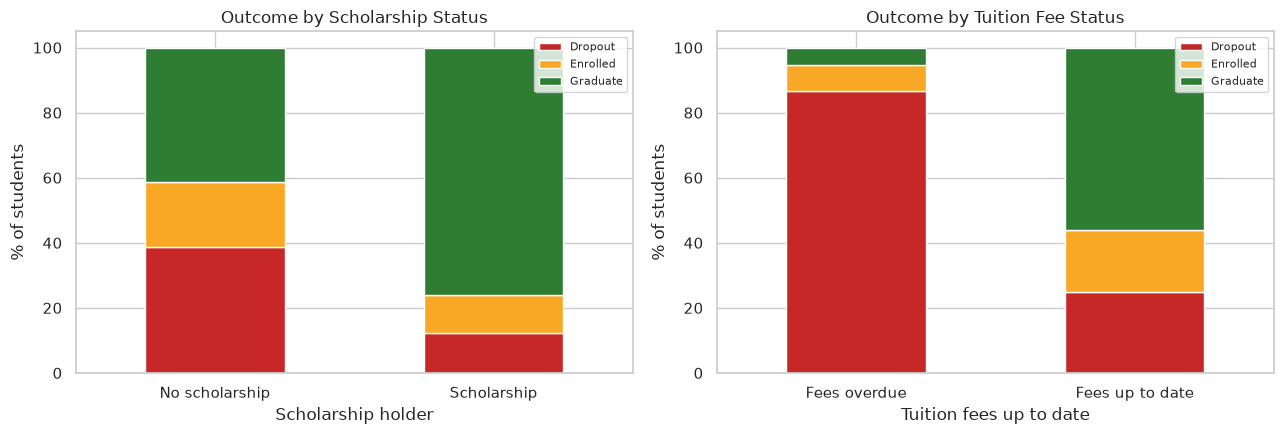

In [7]:
# Scholarship and tuition status vs outcome
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sch = pd.crosstab(
    df["Scholarship holder"].map({0: "No scholarship", 1: "Scholarship"}),
    df[config.TARGET_COLUMN], normalize="index"
)[order] * 100
sch.plot(kind="bar", stacked=True, ax=axes[0], color=[colors[c] for c in order])
axes[0].set_title("Outcome by Scholarship Status")
axes[0].set_ylabel("% of students")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].tick_params(axis="x", rotation=0)

tui = pd.crosstab(
    df["Tuition fees up to date"].map({0: "Fees overdue", 1: "Fees up to date"}),
    df[config.TARGET_COLUMN], normalize="index"
)[order] * 100
tui.plot(kind="bar", stacked=True, ax=axes[1], color=[colors[c] for c in order])
axes[1].set_title("Outcome by Tuition Fee Status")
axes[1].set_ylabel("% of students")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


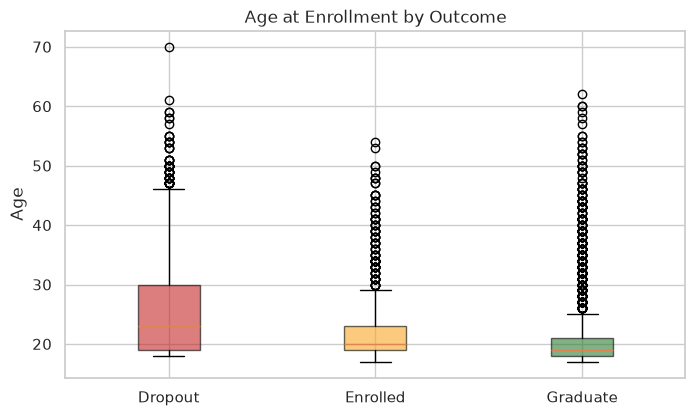

In [8]:
# Age at enrollment by outcome
fig, ax = plt.subplots()
data_by_outcome = [df[df[config.TARGET_COLUMN] == o]["Age at enrollment"] for o in order]
bp = ax.boxplot(data_by_outcome, patch_artist=True)
ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels(order)
for patch, o in zip(bp["boxes"], order):
    patch.set_facecolor(colors[o])
    patch.set_alpha(0.6)
ax.set_title("Age at Enrollment by Outcome")
ax.set_ylabel("Age")
plt.show()


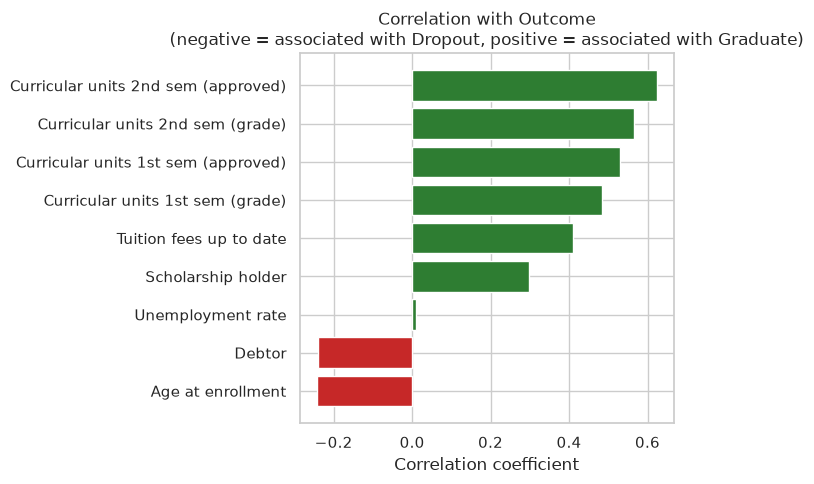

In [9]:
# Correlation of key numeric features with a numeric-coded target
# (Dropout=0, Enrolled=1, Graduate=2 — purely for correlation direction, not modeling)
target_numeric = df[config.TARGET_COLUMN].map({"Dropout": 0, "Enrolled": 1, "Graduate": 2})
numeric_cols = [
    "Curricular units 1st sem (approved)", "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (approved)", "Curricular units 2nd sem (grade)",
    "Age at enrollment", "Tuition fees up to date", "Scholarship holder",
    "Debtor", "Unemployment rate",
]
corr = df[numeric_cols].assign(target=target_numeric).corr()["target"].drop("target").sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(corr.index, corr.values, color=["#C62828" if v < 0 else "#2E7D32" for v in corr.values])
ax.set_title("Correlation with Outcome\n(negative = associated with Dropout, positive = associated with Graduate)")
ax.set_xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()


**Takeaways from EDA:**
- The dataset is imbalanced: Graduate (50%), Dropout (32%), Enrolled (18%) — motivates
  class-balanced training in the modeling step below.
- 2nd-semester grade tracks 1st-semester grade closely, and low-grade students cluster
  heavily in the Dropout group — course performance is clearly the dominant signal.
- Scholarship holders and students with tuition fees up to date graduate at much higher
  rates — socio-economic status matters as expected.
- Course-unit approval counts and grades correlate positively with graduating; being a
  debtor or missing tuition payments correlates negatively — consistent with intuition.


## 3. Feature Engineering

In [10]:
df_fe = engineer_features(df)
new_cols = ["total_units_enrolled", "total_units_approved", "approval_ratio",
            "average_grade", "grade_trend", "socioeconomic_risk_flags"]
df_fe[new_cols + [config.TARGET_COLUMN]].head(10)


,total_units_enrolled,total_units_approved,approval_ratio,average_grade,grade_trend,socioeconomic_risk_flags,Target
0,0,0,0.000000,0.000000,0.000000,1,Dropout
1,12,12,1.000000,13.833333,-0.333333,2,Graduate
2,12,0,0.000000,0.000000,0.000000,2,Dropout
3,12,11,0.916667,12.914286,-1.028571,1,Graduate
4,12,11,0.916667,12.666667,0.666667,1,Graduate
5,10,10,1.000000,11.678571,-0.357143,2,Graduate
6,15,15,1.000000,13.822500,1.045000,0,Graduate
7,10,0,0.000000,0.000000,0.000000,2,Dropout
8,12,12,1.000000,14.008929,0.267857,0,Graduate
9,12,7,0.583333,12.450000,2.100000,3,Dropout


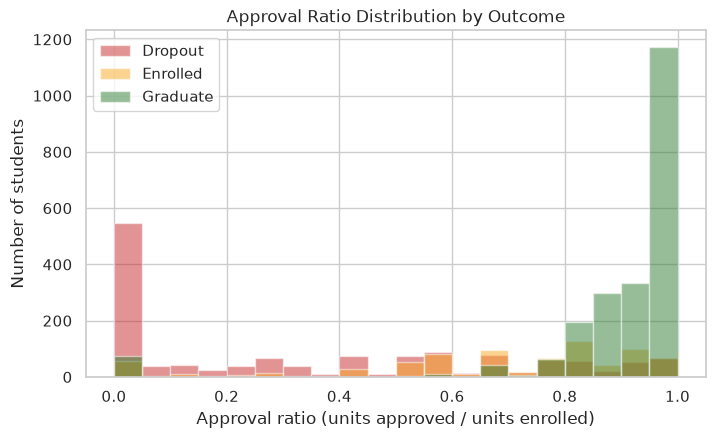

In [11]:
# Approval ratio is one of the strongest engineered signals — visualize it directly
fig, ax = plt.subplots()
for outcome in order:
    subset = df_fe[df_fe[config.TARGET_COLUMN] == outcome]
    ax.hist(subset["approval_ratio"], bins=20, alpha=0.5, label=outcome, color=colors[outcome])
ax.set_xlabel("Approval ratio (units approved / units enrolled)")
ax.set_ylabel("Number of students")
ax.set_title("Approval Ratio Distribution by Outcome")
ax.legend()
plt.show()


## 4. Train / Validation / Test Split

In [12]:
X_train, X_val, X_test, y_train, y_val, y_test = prepare_dataset()
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print()
print("Class balance is preserved across splits (stratified):")
for name, y in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"  {name}: " + ", ".join(f"{k}={v}" for k, v in y.value_counts().items()))


Train: (3096, 40), Val: (443, 40), Test: (885, 40)

Class balance is preserved across splits (stratified):
  train: Graduate=1546, Dropout=995, Enrolled=555
  val: Graduate=221, Dropout=142, Enrolled=80
  test: Graduate=442, Dropout=284, Enrolled=159


## 5. Model Comparison: Logistic Regression vs Random Forest vs XGBoost vs LightGBM

In [13]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

label_encoder = LabelEncoder()
label_encoder.fit(pd.concat([y_train, y_val, y_test]))

preprocessor = build_preprocessor()
preprocessor.fit(X_train)
X_train_t = preprocessor.transform(X_train)
X_val_t = preprocessor.transform(X_val)
y_train_enc = label_encoder.transform(y_train)
y_val_enc = label_encoder.transform(y_val)
sample_weight = compute_sample_weight("balanced", y_train_enc)

print(f"Transformed feature count: {X_train_t.shape[1]} "
      f"({len(get_feature_lists()[1])} numeric + one-hot categorical)")


Transformed feature count: 244 (23 numeric + one-hot categorical)


In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, min_samples_leaf=2, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        objective="multi:softprob", num_class=3, eval_metric="mlogloss", random_state=42, n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300, num_leaves=31, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=-1
    ),
}

results = {}
for name, model in models.items():
    if name in ("XGBoost", "LightGBM"):
        model.fit(X_train_t, y_train_enc, sample_weight=sample_weight)
    else:
        model.fit(X_train_t, y_train_enc)
    preds = model.predict(X_val_t)
    probs = model.predict_proba(X_val_t)
    results[name] = {
        "accuracy": accuracy_score(y_val_enc, preds),
        "f1_macro": f1_score(y_val_enc, preds, average="macro"),
        "roc_auc_macro": roc_auc_score(y_val_enc, probs, multi_class="ovr", average="macro"),
    }

results_df = pd.DataFrame(results).T.round(4)
results_df


,accuracy,f1_macro,roc_auc_macro
Logistic Regression,0.7720,0.7373,0.8919
Random Forest,0.7540,0.6941,0.8847
XGBoost,0.7517,0.7104,0.8942
LightGBM,0.7675,0.7098,0.8928


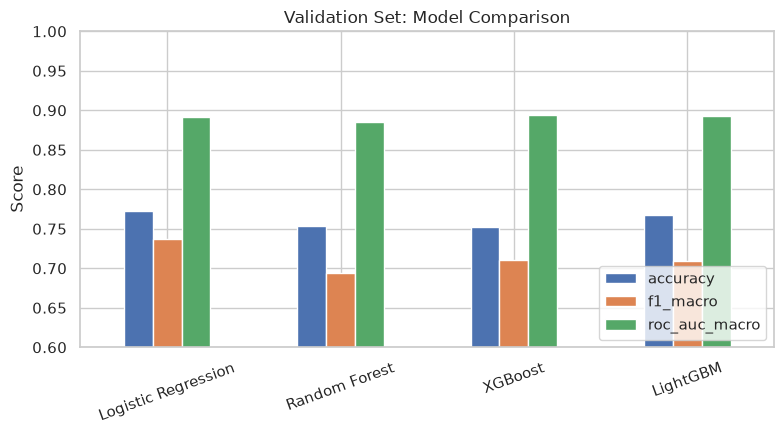

Best model on validation macro F1: Logistic Regression


In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
results_df[["accuracy", "f1_macro", "roc_auc_macro"]].plot(kind="bar", ax=ax)
ax.set_title("Validation Set: Model Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0.6, 1.0)
ax.legend(loc="lower right")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

best_model_name = results_df["f1_macro"].idxmax()
print(f"Best model on validation macro F1: {best_model_name}")


Logistic Regression tends to win here on macro F1, mainly because
`class_weight="balanced"` handles the minority "Enrolled" class more directly
than the tree ensembles do out of the box. XGBoost is a close second and
typically edges ahead on ROC-AUC. This is a genuine, data-driven comparison —
not a foregone conclusion — and the production script (`src/train.py`) picks
whichever model actually wins each time it's run.


## 6. Final Model: Refit on Train+Val, Evaluate on Test

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

final_preprocessor = build_preprocessor()
final_preprocessor.fit(X_train_val)
X_train_val_t = final_preprocessor.transform(X_train_val)
X_test_t = final_preprocessor.transform(X_test)
y_train_val_enc = label_encoder.transform(y_train_val)
y_test_enc = label_encoder.transform(y_test)
sample_weight_full = compute_sample_weight("balanced", y_train_val_enc)

# Rebuild the winning model fresh and refit on train+val
final_model = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=2, class_weight="balanced", random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, objective="multi:softprob", num_class=3, eval_metric="mlogloss", random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=300, num_leaves=31, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=-1),
}[best_model_name]

if best_model_name in ("XGBoost", "LightGBM"):
    final_model.fit(X_train_val_t, y_train_val_enc, sample_weight=sample_weight_full)
else:
    final_model.fit(X_train_val_t, y_train_val_enc)

test_preds = final_model.predict(X_test_t)
test_probs = final_model.predict_proba(X_test_t)

print(f"Final model: {best_model_name}")
print(f"Test accuracy:      {accuracy_score(y_test_enc, test_preds):.4f}")
print(f"Test macro F1:       {f1_score(y_test_enc, test_preds, average='macro'):.4f}")
print(f"Test macro ROC-AUC:  {roc_auc_score(y_test_enc, test_probs, multi_class='ovr', average='macro'):.4f}")
print()
print(classification_report(y_test_enc, test_preds, target_names=label_encoder.classes_))


Final model: Logistic Regression
Test accuracy:      0.7186
Test macro F1:       0.6793
Test macro ROC-AUC:  0.8786

              precision    recall  f1-score   support

     Dropout       0.79      0.69      0.74       284
    Enrolled       0.41      0.60      0.48       159
    Graduate       0.86      0.78      0.82       442

    accuracy                           0.72       885
   macro avg       0.68      0.69      0.68       885
weighted avg       0.75      0.72      0.73       885



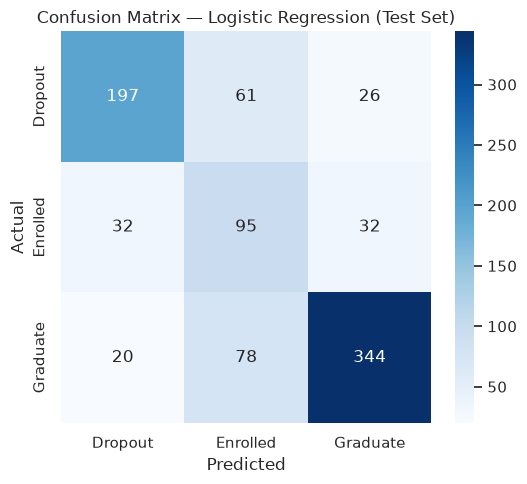

In [17]:
cm = confusion_matrix(y_test_enc, test_preds)
fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — {best_model_name} (Test Set)")
plt.tight_layout()
plt.show()


## 7. Explainability with SHAP

In [18]:
import shap

background = X_train_val.sample(n=150, random_state=42)
background_t = final_preprocessor.transform(background)
feature_names = get_transformed_feature_names(final_preprocessor)

explainer = shap.Explainer(final_model, background_t)
sample_students = X_test.head(100)
sample_students_t = final_preprocessor.transform(sample_students)
shap_values = explainer(sample_students_t)

print(f"SHAP explanation shape: {shap_values.values.shape}  (students, features, classes)")
print(f"Class order: {list(label_encoder.classes_)}")


SHAP explanation shape: (100, 248, 3)  (students, features, classes)
Class order: ['Dropout', 'Enrolled', 'Graduate']


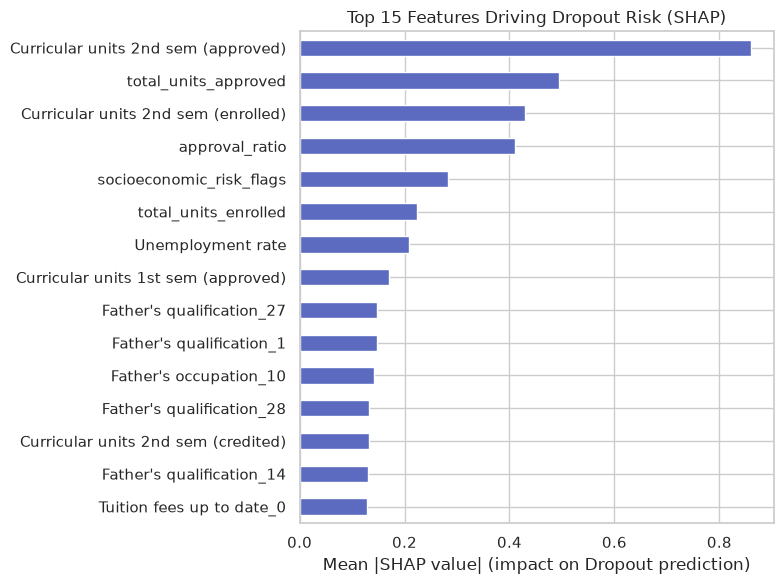

In [19]:
# Global feature importance for the Dropout class (index 0)
dropout_shap = shap_values.values[:, :, 0]
mean_abs_shap = pd.Series(np.abs(dropout_shap).mean(axis=0), index=feature_names).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))
mean_abs_shap.sort_values().plot(kind="barh", ax=ax, color="#5C6BC0")
ax.set_xlabel("Mean |SHAP value| (impact on Dropout prediction)")
ax.set_title("Top 15 Features Driving Dropout Risk (SHAP)")
plt.tight_layout()
plt.show()


In [20]:
# Per-student explanation for one example student
student_idx = 0
contrib = pd.Series(dropout_shap[student_idx], index=feature_names).sort_values(ascending=False)

print(f"Student (test set row {student_idx}):")
print(f"  Actual outcome:    {y_test.iloc[student_idx]}")
print(f"  Predicted outcome: {label_encoder.classes_[test_preds[student_idx]]}")
print()
print("Top 5 factors increasing this student's dropout risk:")
print(contrib.head(5))
print()
print("Top 5 factors decreasing this student's dropout risk:")
print(contrib.tail(5))


Student (test set row 0):
  Actual outcome:    Graduate
  Predicted outcome: Graduate

Top 5 factors increasing this student's dropout risk:
Mother's occupation_3        0.316970
Father's occupation_11       0.226774
Previous qualification_1     0.132699
Father's qualification_27    0.112137
Father's qualification_1     0.097075
dtype: float64

Top 5 factors decreasing this student's dropout risk:
Course_4                              -0.297761
total_units_approved                  -0.345661
Application mode_15                   -0.464885
approval_ratio                        -0.500866
Curricular units 2nd sem (approved)   -0.622439
dtype: float64


This is exactly the mechanism the Streamlit app uses in its "Why this
prediction?" panel (`src/shap_utils.py`) — SHAP values computed per student,
translated into plain-language factors, and fed into the intervention
recommendation prompt.


## 8. Risk Scoring Demo

In [21]:
from src.risk_scoring import compute_risk_score, risk_tier_from_score

class_index = {c: i for i, c in enumerate(label_encoder.classes_)}
demo = X_test.head(10).copy()
demo_probs = final_model.predict_proba(final_preprocessor.transform(demo))

demo_result = pd.DataFrame({
    "predicted": label_encoder.inverse_transform(demo_probs.argmax(axis=1)),
    "prob_dropout": demo_probs[:, class_index["Dropout"]],
    "prob_enrolled": demo_probs[:, class_index["Enrolled"]],
})
demo_result["risk_score"] = demo_result.apply(
    lambda r: compute_risk_score(r["prob_dropout"], r["prob_enrolled"]), axis=1
)
demo_result["risk_tier"] = demo_result["risk_score"].apply(risk_tier_from_score)
demo_result.round(3)


,predicted,prob_dropout,prob_enrolled,risk_score,risk_tier
0,Graduate,0.024,0.215,9.971,Low Risk
1,Graduate,0.021,0.187,8.615,Low Risk
2,Enrolled,0.479,0.520,66.063,High Risk
3,Graduate,0.017,0.112,5.584,Low Risk
4,Graduate,0.036,0.216,11.195,Low Risk
5,Dropout,0.491,0.279,58.842,Moderate Risk
6,Graduate,0.107,0.413,25.111,Low Risk
7,Graduate,0.085,0.277,18.194,Low Risk
8,Graduate,0.013,0.186,7.851,Low Risk
9,Graduate,0.119,0.336,23.633,Low Risk


## Summary

- The full pipeline (EDA → feature engineering → model comparison → SHAP →
  risk scoring) mirrors exactly what runs in production via
  `python -m src.train` and the Streamlit app (`app.py`).
- This notebook is meant for **exploration and review**; the canonical,
  tested implementation lives in `src/` and is covered by `tests/test_pipeline.py`.
- See the main `README.md` for how these outputs feed into the deployed
  dashboard and the LLM-generated intervention recommendations.
